## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
nombre_estudiante = "Thaliana Rocío Sierra, Juan José Mican, Alejandro Gil León, Mariana Shenoa Castiblanco"

## 1) Descripción del problema **[1 pts]**

Desarrollar un programa que, dado un valor de cambio en pesos colombianos, determine la menor cantidad de monedas necesarias para entregar exactamente dicho cambio utilizando las denominaciones disponibles: 50, 100, 200, 500 y 1000 pesos.


## 2) Requerimientos **[2 pts]**

### Funcionales
- Solicitar al usuario el valor del cambio.
- Utilizar las monedas [50, 100, 200, 500, 1000].
- Calcular la cantidad mínima de monedas.
- Mostrar las monedas utilizadas.
- Informar si el cambio no puede entregarse exactamente.
### No funcionales
- El programa debe ser fácil de entender.
- Debe ejecutarse correctamente para diferentes valores.
- Debe entregar el resultado rápidamente.
- El código debe ser ejecutable en Python.


## 3) Historias de usuario **[2 pts]**
**Historia 1:** Ingresar el cambio
Como cajero, quiero ingresar el valor del cambio para que el programa pueda calcular las monedas necesarias.
Criterio de aceptación: Al ingresar un valor válido, el programa debe iniciar el cálculo del cambio.

**Historia 2:** Calcular la cantidad mínima
Como cajero, quiero que el programa calcule la menor cantidad de monedas posible para entregar el cambio.
Criterio de aceptación: Si ingreso 1850, el programa debe determinar que se necesitan 5 monedas.

**Historia 3:** Mostrar las monedas utilizadas
Como cajero, quiero conocer las denominaciones de las monedas utilizadas para poder entregar el cambio al cliente.
Criterio de aceptación: Para 1850, el programa debe mostrar 1000 + 500 + 200 + 100 + 50.

**Historia 4:** Validar el cambio
Como cajero, quiero que el programa identifique cuando un valor no puede entregarse exactamente con las monedas disponibles.
Criterio de aceptación: Si ingreso 25, el programa debe informar que no es posible entregar exactamente ese cambio.

**Historia 5:** Validar valores ingresados
Como cajero, quiero que el programa valide que el valor del cambio sea válido antes de realizar el cálculo.
Criterio de aceptación: Si ingreso un valor negativo, el programa debe informar que el valor ingresado no es válido.


## 4) Diagramas de flujo **[5 pts]**

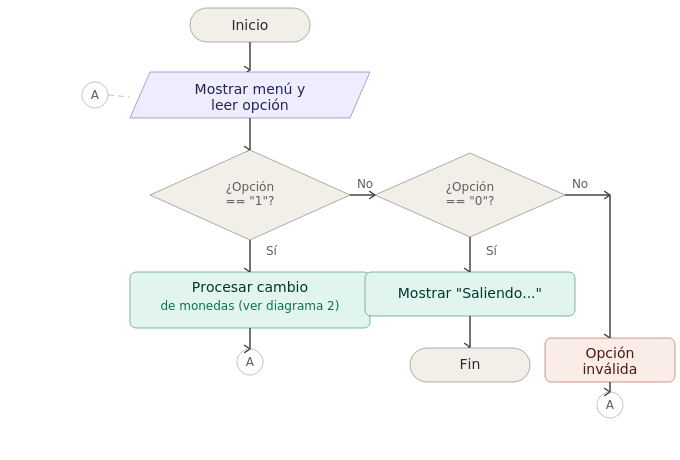


## 5) Diagramas de secuencia **[5 pts]**

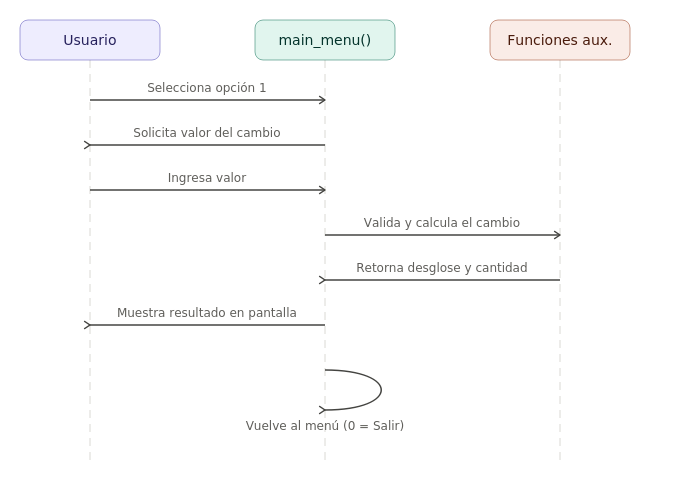

El diagrama representa el flujo general del programa "Cambio en monedas":

**Usuario → main_menu():** el usuario selecciona la opción 1 en el menú.

**main_menu() → Usuario:** el sistema solicita el valor del cambio.

**Usuario → main_menu():** el usuario ingresa el valor.

**main_menu() → Funciones aux.:** se invoca get_valid_number() para validar la entrada y calcular_cambio_dp() para calcular el desglose mínimo de monedas.

**Funciones aux. → main_menu():** se retorna el desglose y la cantidad mínima de monedas.

**main_menu() → Usuario:** se muestra el resultado en pantalla.

**Bucle:** el while True hace que el menú se repita hasta que el usuario elige la opción 0 para salir.

Este diagrama muestra el proceso general de interacción, sin entrar en el detalle interno de cada función (por ejemplo, cómo calcular_cambio_dp resuelve el problema de programación dinámica).

## 6) Diagramas de casos de uso **[5 pts]**

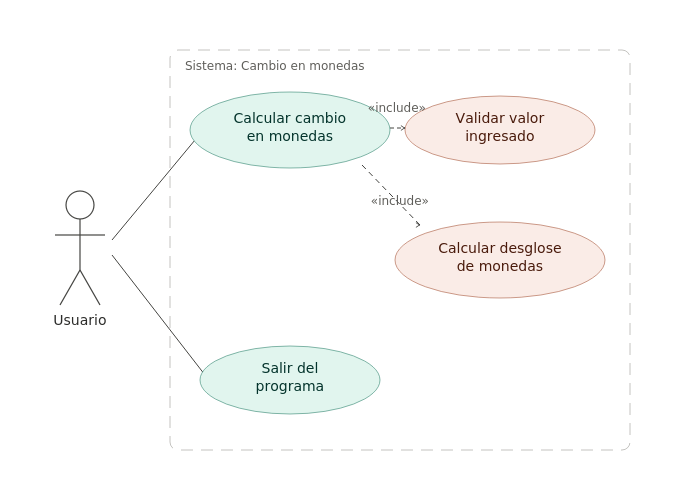

Usuario (actor) interactúa directamente con dos casos de uso principales: Calcular cambio en monedas y Salir del programa — que corresponden a las dos opciones del menú (1 y 0).

El caso Calcular cambio en monedas incluye («include») dos sub-casos que siempre ocurren como parte de él: Validar valor ingresado (la función get_valid_number) y Calcular desglose de monedas (la función calcular_cambio_dp).

## 7) Análisis de complejidad **[5 pts]**

$T(N) = 5n^2$

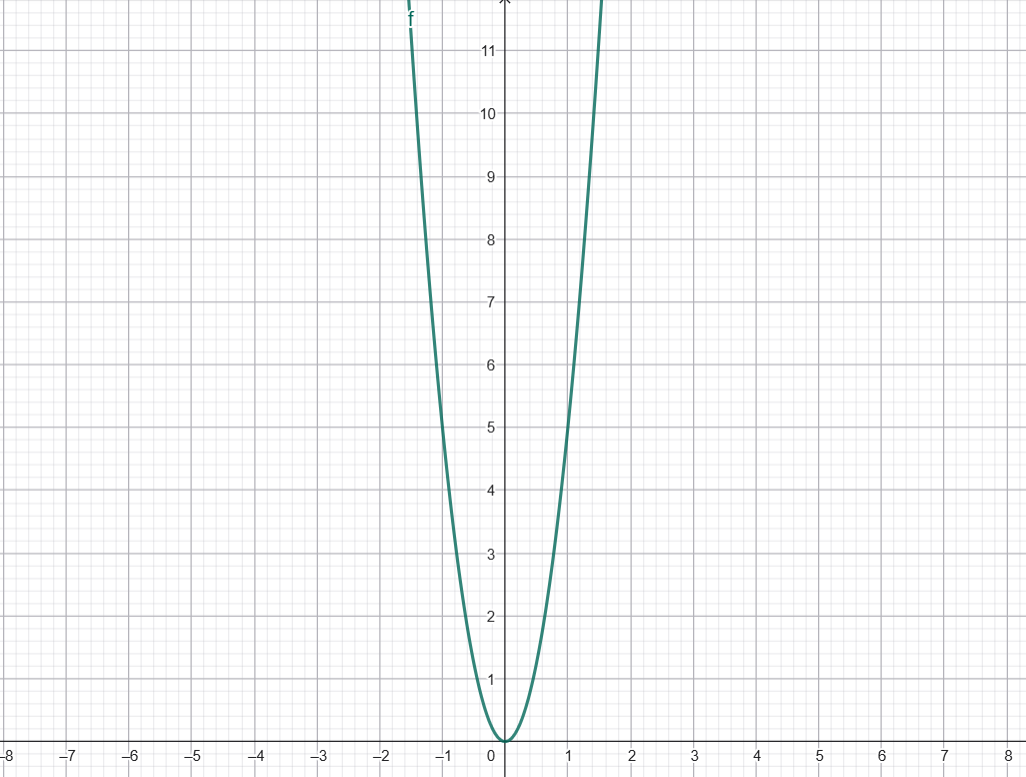


## 8) Código funcional **[10 pts]**


In [1]:
# Code

def get_valid_number(prompt):
    while True:
        user_input = input(prompt).strip()
        if user_input.isdigit():
            return int(user_input)
        print("\n\tError: Por favor, ingrese solo dígitos (no letras, espacios ni símbolos).")

def calculate_change(change_value):
    colombian_coins = [50, 100, 200, 500, 1000]

    dp = [float('inf')] * (change_value + 1)
    dp[0] = 0

    used_coin = [0] * (change_value + 1)

    for i in range(1, change_value + 1):
        for coin in colombian_coins:
            if i >= coin and dp[i - coin] + 1 < dp[i]:
                dp[i] = dp[i - coin] + 1
                used_coin[i] = coin

    if dp[change_value] == float('inf'):
        return None, []

    coins_result = []
    actual = change_value
    while actual > 0:
        coin = used_coin[actual]
        coins_result.append(coin)
        actual -= coin

    return dp[change_value], sorted(coins_result, reverse=True)

def main_menu():
    while True:
        print("\n\t\t--CAMBIO EN MONEDAS by FairSociety--")
        print("\n\t\t\t--- MENÚ PRINCIPAL ---")
        print("\n\t1. Ingresar valor del cambio que necesita")
        print("\t0. Salir")

        option = input("\n\t\tSeleccione una opción: ").strip()

        if option == "1":
            change = get_valid_number("\n\tIngrese el valor del cambio (< 1,000,000): ")

            if change >= 1000000:
                print("\n\tError: El monto excede el límite del sistema. Ingrese un valor menor a 1,000,000.")
                continue

            residuo = change % 50

            if residuo != 0:
                valor_original = change
                if residuo >= 25:
                    change = change + (50 - residuo)
                else:
                    change = change - residuo

                print(f"\n\t[!] Aviso: El valor {valor_original} no es múltiplo de 50.")
                print(f"\t[!] Se ha redondeado automáticamente a: {change}")

            quantity, desglose = calculate_change(change)

            if quantity is None:
                print("\n\tError: No es posible dar un cambio exacto con las monedas disponibles.")
            elif quantity == 0:
                print("\n\tEl cambio es 0. No se necesitan monedas.")
            else:
                sum_str = " + ".join(map(str, desglose))
                print(f"\n\tDesglose: {sum_str} = {change}")
                print(f"\tCantidad mínima de monedas: {quantity}")

        elif option == "0":
            print("\n\n\tSaliendo del programa...\n")
            break
        else:
            print("Opción inválida. Intente de nuevo.")

if __name__ == "__main__":
    pass

In [ ]:
main_menu()


		--CAMBIO EN MONEDAS by FairSociety--

			--- MENÚ PRINCIPAL ---

	1. Ingresar valor del cambio que necesita
	0. Salir


## 9) pruebas **[15 pts]**

In [5]:
def test(change_value, expected_output):
    got_output, desglose = calculate_change(change_value)

    if got_output == expected_output:
        print(f"Paso caso de prueba {change_value} -> {expected_output}")
    else:
        print(f"Error en prueba {change_value}: se obtuvo {got_output}, pero se esperaba {expected_output}")

## Pruebas de enunciado

¿Qué va aquí?

Casos de prueba proporcionados por el enunciado.

Entrada usada. 1850

Salida esperada. 5

Salida obtenida. 5

In [7]:
test(1850, 5)

Paso caso de prueba 1850 -> 5


## Pruebas propias
¿Qué va aquí?

Casos creados por usted. 5550

Salida esperada. 7

Salida obtenida. 7


In [11]:
test(5550, 7)

Paso caso de prueba 5550 -> 7


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking

Generando datos .............

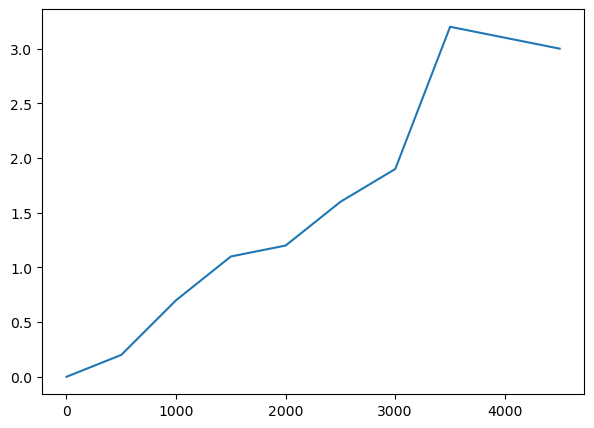

In [35]:
def bench(n: int, step: int = 1) -> list[tuple[int, float]]:
    print("Generando datos ...", end="")
    from random import randint
    import time

    results: list[tuple[int, float]] = []

    # AJUSTAR LAS ENTRADAS SEGÚN EL PROBLEMA
    for size in range(1, n, step):
        valor_entrada = size  # Guardamos el tamaño en una variable limpia

        ti = time.perf_counter()
        output = calculate_change(valor_entrada)  # Tu función del archivo
        tf = time.perf_counter()

        delta = (tf - ti) * 1000
        print(".", end="")
        results.append((size, delta))
    return results


# === CODIGO PARA DIBUJAR ===


def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)
    import matplotlib.pyplot as plt

    plt.figure(figsize=dimensiones)
    plt.plot(x, y)
    plt.show()


# === LLAMADO ===
# Probamos con montos de hasta 5000 saltando de 500 en 500
tiempos = bench(5000, step=500)

x = [size for size, timing in tiempos]
y = [timing for size, timing in tiempos]

dibujar(x, y)